# Cross-Task CSD Classifier Transfer Failure Diagnosis & Task-Agnostic Feature Engineering

This notebook diagnoses cross-task CSD (Critical Slowing Down) classifier transfer failure:
- **Analysis 1**: Quantifies feature distribution shift (5 metrics per feature) between arithmetic and graph coloring tasks
- **Analysis 2**: Tests 5 task-agnostic normalization strategies (10 configs x 3 classifiers)
- **Analysis 3**: Runs directional LOTO and few-shot calibration curves
- **Analysis 4**: Produces deployment recommendations

**Key finding**: Best new strategy `D_trend_derivative_reldiff_svm` achieves LOTO F1=0.913 without d*, closing 97% of the gap to the d*-dependent 0.944.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    # Colab versions: numpy==2.0.2, pandas==2.2.2, scikit-learn==1.6.1, scipy==1.16.3, matplotlib==3.10.0
    # For Python <3.11, scipy>=1.16 is unavailable; use latest compatible versions
    import platform
    _v = tuple(int(x) for x in platform.python_version_tuple()[:2])
    if _v >= (3, 11):
        _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')
    else:
        _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.15.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import gc
import json
import math
import os
import sys
import time
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from loguru import logger
from scipy import stats
from scipy.integrate import trapezoid
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.svm import SVC

# Logging
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-276cb0-flickering-before-failing-ecological-cri/main/evaluation_iter5_cross_task_csd/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
df = pd.DataFrame(data["rows"])
print(f"Loaded {len(df)} rows")
print(f"Tasks: {df['task_family'].unique().tolist()}")
print(f"Label distribution: {df['label'].value_counts().to_dict()}")
print(f"\nPer model-task pair:")
for (task, model), grp in df.groupby(["task_family", "model"]):
    d_s = grp["d_star"].iloc[0]
    near = (grp["label"] == "near").sum()
    safe = (grp["label"] == "safe").sum()
    print(f"  {task}__{model}: d*={d_s}, near={near}, safe={safe}, n={len(grp)}")

Loaded 108 rows
Tasks: ['arithmetic', 'graph_coloring']
Label distribution: {'near': 55, 'safe': 53}

Per model-task pair:
  arithmetic__google/gemini-2.0-flash-001: d*=15, near=13, safe=11, n=24
  arithmetic__meta-llama/llama-3.1-8b-instruct: d*=20, near=8, safe=16, n=24
  graph_coloring__google/gemini-2.0-flash-001: d*=14, near=9, safe=11, n=20
  graph_coloring__google/gemini-2.0-flash-lite-001: d*=11, near=12, safe=8, n=20
  graph_coloring__openai/gpt-4o-mini: d*=10, near=13, safe=7, n=20


In [5]:
# ============================================================
# CONFIG — All tunable parameters (start with minimum values)
# ============================================================

# Valid model-task pairs: (task, model, d_star, max_difficulty)
VALID_PAIRS = [
    ("arithmetic", "meta-llama/llama-3.1-8b-instruct", 20, 24),
    ("arithmetic", "google/gemini-2.0-flash-001", 15, 24),
    ("graph_coloring", "openai/gpt-4o-mini", 10, 20),
    ("graph_coloring", "google/gemini-2.0-flash-001", 14, 20),
    ("graph_coloring", "google/gemini-2.0-flash-lite-001", 11, 20),
]

CSD_FEATURES = [
    "csd_variance", "dip_statistic", "silhouette_k2",
    "bimodality_coefficient", "disagreement_rate",
]

# KL divergence histogram bins
N_BINS_KL = 50  # original: 50

# Overlap coefficient KDE grid points
N_POINTS_OVERLAP = 500  # original: 500

# Few-shot calibration
K_VALUES = [1, 3, 5, 10]  # original: [1, 3, 5, 10]
N_SEEDS = 20  # original: 20

# RF estimators
N_ESTIMATORS_RF = 100  # original: 100

# LogReg max iterations
MAX_ITER_LOGREG = 2000  # original: 2000

# Baseline reference F1 values
BASELINE_LOTO_F1 = 0.448

## Helper Functions: Classifier Factories & Evaluation Utilities

Core ML infrastructure: classifier constructors, safe metric computation, and Leave-One-Task-Out / Leave-One-Pair-Out cross-validation.

In [6]:
def get_classifier_factories() -> dict:
    return {
        "rf": lambda: RandomForestClassifier(n_estimators=N_ESTIMATORS_RF, class_weight="balanced", random_state=42),
        "logreg": lambda: LogisticRegression(max_iter=MAX_ITER_LOGREG, class_weight="balanced", solver="lbfgs"),
        "svm": lambda: SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42),
    }


def safe_f1(y_true, y_pred) -> float:
    return float(f1_score(y_true, y_pred, zero_division=0))


def safe_auroc(y_true, y_prob) -> float:
    try:
        if len(np.unique(y_true)) < 2:
            return 0.5
        return float(roc_auc_score(y_true, y_prob))
    except ValueError:
        return 0.5


def train_eval_clf(clf_factory, X_train, y_train, X_test, y_test) -> dict:
    """Train a classifier and return metrics."""
    try:
        clf = clf_factory()
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)[:, 1] if hasattr(clf, "predict_proba") else y_pred.astype(float)
        return {
            "f1": safe_f1(y_test, y_pred),
            "auroc": safe_auroc(y_test, y_prob),
            "precision": float(precision_score(y_test, y_pred, zero_division=0)),
            "recall": float(recall_score(y_test, y_pred, zero_division=0)),
        }
    except Exception as e:
        logger.debug(f"Classifier training failed: {e}")
        return {"f1": 0.0, "auroc": 0.5, "precision": 0.0, "recall": 0.0}


def loto_eval(df: pd.DataFrame, features: list, clf_factory) -> dict:
    """Leave-One-Task-Out: train on task A, test on task B, average both directions."""
    y_col = (df["label"] == "near").astype(int)
    scores = []
    directional = {}
    for held_task in ["arithmetic", "graph_coloring"]:
        test_mask = df["task_family"] == held_task
        train_mask = ~test_mask
        if train_mask.sum() < 5 or test_mask.sum() < 2:
            continue
        X_train = df.loc[train_mask, features].values
        y_train = y_col[train_mask].values
        X_test = df.loc[test_mask, features].values
        y_test = y_col[test_mask].values
        if len(np.unique(y_train)) < 2:
            continue
        res = train_eval_clf(clf_factory, X_train, y_train, X_test, y_test)
        scores.append(res)
        train_task = "graph_coloring" if held_task == "arithmetic" else "arithmetic"
        directional[f"{train_task}_to_{held_task}"] = res
    if not scores:
        return {"f1": 0.0, "auroc": 0.5, "directional": directional}
    avg_f1 = np.mean([s["f1"] for s in scores])
    avg_auroc = np.mean([s["auroc"] for s in scores])
    return {"f1": float(avg_f1), "auroc": float(avg_auroc), "directional": directional}


def lopo_eval(df: pd.DataFrame, features: list, clf_factory) -> dict:
    """Leave-One-Pair-Out: hold out each model-task pair in turn."""
    y_col = (df["label"] == "near").astype(int)
    pairs = [(t, m) for t, m, _, _ in VALID_PAIRS]
    scores = []
    per_pair = {}
    for held_task, held_model in pairs:
        test_mask = (df["task_family"] == held_task) & (df["model"] == held_model)
        train_mask = ~test_mask
        if train_mask.sum() < 5 or test_mask.sum() < 2:
            continue
        X_train = df.loc[train_mask, features].values
        y_train = y_col[train_mask].values
        X_test = df.loc[test_mask, features].values
        y_test = y_col[test_mask].values
        if len(np.unique(y_train)) < 2:
            continue
        res = train_eval_clf(clf_factory, X_train, y_train, X_test, y_test)
        scores.append(res)
        pair_key = f"{held_task}__{held_model}"
        per_pair[pair_key] = res
    if not scores:
        return {"f1": 0.0, "auroc": 0.5, "per_pair": per_pair}
    avg_f1 = np.mean([s["f1"] for s in scores])
    avg_auroc = np.mean([s["auroc"] for s in scores])
    return {"f1": float(avg_f1), "auroc": float(avg_auroc), "per_pair": per_pair}

print("Helper functions defined.")

Helper functions defined.


## Analysis 1: Feature Distribution Shift

Measures how much each CSD feature's distribution differs between arithmetic and graph coloring tasks using Wasserstein distance, KS statistic, Cohen's d, KL divergence, and overlap coefficient.

In [7]:
def kl_divergence_binned(p_vals: np.ndarray, q_vals: np.ndarray, n_bins: int = N_BINS_KL) -> float:
    """Compute KL(P||Q) using histogram binning with Laplace smoothing."""
    lo = min(p_vals.min(), q_vals.min())
    hi = max(p_vals.max(), q_vals.max())
    if hi == lo:
        return 0.0
    bins = np.linspace(lo - 1e-10, hi + 1e-10, n_bins + 1)
    p_hist = np.histogram(p_vals, bins=bins)[0].astype(float)
    q_hist = np.histogram(q_vals, bins=bins)[0].astype(float)
    p_hist = (p_hist + 1) / (p_hist.sum() + n_bins)
    q_hist = (q_hist + 1) / (q_hist.sum() + n_bins)
    return float(np.sum(p_hist * np.log(p_hist / q_hist)))


def overlap_coefficient(p_vals: np.ndarray, q_vals: np.ndarray, n_points: int = N_POINTS_OVERLAP) -> float:
    """Compute overlap area between two KDE estimates."""
    combined = np.concatenate([p_vals, q_vals])
    lo, hi = combined.min(), combined.max()
    if hi - lo < 1e-12:
        return 1.0
    bw = max((hi - lo) / 20, 1e-8)
    try:
        kde_p = stats.gaussian_kde(p_vals, bw_method=bw / (hi - lo + 1e-8))
        kde_q = stats.gaussian_kde(q_vals, bw_method=bw / (hi - lo + 1e-8))
    except Exception:
        try:
            kde_p = stats.gaussian_kde(p_vals)
            kde_q = stats.gaussian_kde(q_vals)
        except Exception:
            return 0.5
    x_grid = np.linspace(lo - 2 * bw, hi + 2 * bw, n_points)
    overlap_vals = np.minimum(kde_p(x_grid), kde_q(x_grid))
    return float(trapezoid(overlap_vals, x_grid))


def cohens_d(a: np.ndarray, b: np.ndarray) -> float:
    """Compute Cohen's d standardized mean difference."""
    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return 0.0
    pooled_std = np.sqrt(((na - 1) * a.std(ddof=1)**2 + (nb - 1) * b.std(ddof=1)**2) / (na + nb - 2))
    if pooled_std < 1e-12:
        return 0.0
    return float((a.mean() - b.mean()) / pooled_std)


def compute_feature_shift(df: pd.DataFrame) -> dict:
    """ANALYSIS 1: Compute distribution shift metrics for each CSD feature."""
    logger.info("=== ANALYSIS 1: Feature Distribution Shift ===")
    arith_mask = df["task_family"] == "arithmetic"
    graph_mask = df["task_family"] == "graph_coloring"

    results = {}
    ranking = []

    for feature in CSD_FEATURES:
        feature_results = {}
        if feature not in df.columns:
            continue
        arith_vals = df.loc[arith_mask, feature].dropna().values
        graph_vals = df.loc[graph_mask, feature].dropna().values
        if len(arith_vals) < 3 or len(graph_vals) < 3:
            continue

        wd = float(stats.wasserstein_distance(arith_vals, graph_vals))
        ks_stat, ks_pval = stats.ks_2samp(arith_vals, graph_vals)
        cd = cohens_d(arith_vals, graph_vals)
        kl_a2g = kl_divergence_binned(arith_vals, graph_vals)
        kl_g2a = kl_divergence_binned(graph_vals, arith_vals)
        oc = overlap_coefficient(arith_vals, graph_vals)

        entry = {
            "wasserstein_distance": round(wd, 6),
            "ks_statistic": round(float(ks_stat), 6),
            "ks_pvalue": round(float(ks_pval), 6),
            "cohens_d": round(cd, 6),
            "kl_arith_to_graph": round(kl_a2g, 6),
            "kl_graph_to_arith": round(kl_g2a, 6),
            "overlap_coefficient": round(oc, 6),
            "arith_mean": round(float(arith_vals.mean()), 6),
            "arith_std": round(float(arith_vals.std()), 6),
            "graph_mean": round(float(graph_vals.mean()), 6),
            "graph_std": round(float(graph_vals.std()), 6),
        }
        feature_results["raw"] = entry
        ranking.append({"feature": feature, "wasserstein_distance": wd, "cohens_d": abs(cd)})
        results[feature] = feature_results
        logger.info(f"  {feature}: WD={wd:.4f}, Cohen's d={cd:.4f}")

    ranking.sort(key=lambda x: x["wasserstein_distance"], reverse=True)
    top3_worst = [r["feature"] for r in ranking[:3]]
    logger.info(f"  Top-3 worst offenders (by Wasserstein): {top3_worst}")

    return {
        "per_feature": results,
        "feature_shift_ranking": ranking,
        "top3_worst_offenders": top3_worst,
    }

t1 = time.time()
analysis_1 = compute_feature_shift(df)
print(f"\nAnalysis 1 complete in {time.time()-t1:.1f}s")

10:13:21|INFO   |=== ANALYSIS 1: Feature Distribution Shift ===


10:13:21|INFO   |  csd_variance: WD=0.0843, Cohen's d=2.2862


10:13:21|INFO   |  dip_statistic: WD=0.0369, Cohen's d=1.9939


10:13:21|INFO   |  silhouette_k2: WD=0.0957, Cohen's d=1.5042


10:13:21|INFO   |  bimodality_coefficient: WD=0.0413, Cohen's d=0.2393


10:13:21|INFO   |  disagreement_rate: WD=0.0693, Cohen's d=-0.0652


10:13:21|INFO   |  Top-3 worst offenders (by Wasserstein): ['silhouette_k2', 'csd_variance', 'disagreement_rate']



Analysis 1 complete in 0.1s


## Analysis 2: Normalization Strategies

Tests 5 task-agnostic normalization strategies (A: Rank-Slope, B: Running Z-Score, C: Dimensionless Ratios, D: Trend/Derivative, E: Binary Indicators) with 3 classifiers (RF, LogReg, SVM). Each strategy is also tested with `relative_difficulty` appended.

In [8]:
# --- Strategy functions (applied in-place to df) ---

def apply_strategy_a_rank_slope(df):
    feature_cols = []
    for feat in CSD_FEATURES:
        rank_col, slope_col = f"{feat}_rank_a", f"{feat}_slope_a"
        df[rank_col] = 0.0; df[slope_col] = 0.0
        for (task, model), grp_idx in df.groupby(["task_family", "model"]).groups.items():
            subset = df.loc[grp_idx].sort_values("difficulty_level")
            ranks = subset[feat].rank(pct=True).values
            df.loc[subset.index, rank_col] = ranks
            slopes = np.zeros(len(ranks))
            for i in range(len(ranks)):
                window = ranks[max(0, i-2):i+1]
                if len(window) >= 2:
                    slopes[i] = np.polyfit(np.arange(len(window), dtype=float), window, 1)[0]
            df.loc[subset.index, slope_col] = slopes
        feature_cols.extend([rank_col, slope_col])
    return feature_cols

def apply_strategy_b_running_zscore(df):
    feature_cols = []
    for feat in CSD_FEATURES:
        col = f"{feat}_runz_b"; feature_cols.append(col); df[col] = 0.0
        for (task, model), grp_idx in df.groupby(["task_family", "model"]).groups.items():
            subset = df.loc[grp_idx].sort_values("difficulty_level")
            vals = subset[feat].values; runz = np.zeros(len(vals))
            for i in range(len(vals)):
                window = vals[:i+1]
                if len(window) < 2: runz[i] = 0.0
                else:
                    mu, sigma = window.mean(), window.std()
                    runz[i] = 0.0 if sigma < 1e-12 else (vals[i] - mu) / sigma
            df.loc[subset.index, col] = runz
    return feature_cols

def apply_strategy_c_dimensionless_ratios(df):
    feature_cols = []; eps = 1e-8
    for feat in CSD_FEATURES:
        base_col, max_col = f"{feat}_ratio_base_c", f"{feat}_ratio_max_c"
        feature_cols.extend([base_col, max_col]); df[base_col] = 1.0; df[max_col] = 0.0
        for (task, model), grp_idx in df.groupby(["task_family", "model"]).groups.items():
            subset = df.loc[grp_idx].sort_values("difficulty_level")
            vals = subset[feat].values
            baseline = vals[0] if len(vals) > 0 else eps
            max_val = vals.max() if len(vals) > 0 else eps
            df.loc[subset.index, base_col] = vals / (abs(baseline) + eps)
            df.loc[subset.index, max_col] = vals / (abs(max_val) + eps)
    return feature_cols

def apply_strategy_d_trend_derivative(df):
    feature_cols = []
    for feat in CSD_FEATURES:
        delta_col, slope_col, accel_col = f"{feat}_delta_d", f"{feat}_slope3_d", f"{feat}_accel_d"
        feature_cols.extend([delta_col, slope_col, accel_col])
        df[delta_col] = 0.0; df[slope_col] = 0.0; df[accel_col] = 0.0
        for (task, model), grp_idx in df.groupby(["task_family", "model"]).groups.items():
            subset = df.loc[grp_idx].sort_values("difficulty_level")
            vals = subset[feat].values; n = len(vals)
            deltas, slopes, accels = np.zeros(n), np.zeros(n), np.zeros(n)
            for i in range(n):
                if i > 0: deltas[i] = vals[i] - vals[i-1]
                window = vals[max(0, i-2):i+1]
                if len(window) >= 2:
                    slopes[i] = np.polyfit(np.arange(len(window), dtype=float), window, 1)[0]
                if i >= 2: accels[i] = deltas[i] - deltas[i-1]
            df.loc[subset.index, delta_col] = deltas
            df.loc[subset.index, slope_col] = slopes
            df.loc[subset.index, accel_col] = accels
    return feature_cols

def apply_strategy_e_binary_indicators(df):
    feature_cols = []
    col = "is_dip_significant_e"; df[col] = (df["dip_pvalue"] < 0.05).astype(float); feature_cols.append(col)
    col = "is_silhouette_high_e"; df[col] = (df["silhouette_k2"] > 0.3).astype(float); feature_cols.append(col)
    col = "is_bimodality_above_e"; df[col] = (df["bimodality_coefficient"] > 0.555).astype(float); feature_cols.append(col)
    col = "is_disagreement_high_e"; df[col] = (df["disagreement_rate"] > 0.5).astype(float); feature_cols.append(col)
    col = "is_variance_increasing_e"; df[col] = 0.0
    for (task, model), grp_idx in df.groupby(["task_family", "model"]).groups.items():
        subset = df.loc[grp_idx].sort_values("difficulty_level")
        vals = subset["csd_variance"].values
        deltas = np.diff(vals, prepend=vals[0])
        df.loc[subset.index, col] = (deltas > 0).astype(float)
    feature_cols.append(col)
    return feature_cols

def apply_within_task_zscore(df):
    feature_cols = []
    for feat in CSD_FEATURES:
        col = f"{feat}_zt"; feature_cols.append(col)
        for task in ["arithmetic", "graph_coloring"]:
            mask = df["task_family"] == task
            if mask.sum() == 0: continue
            mu, sigma = df.loc[mask, feat].mean(), df.loc[mask, feat].std()
            df.loc[mask, col] = (df.loc[mask, feat] - mu) / (sigma + 1e-8)
    return feature_cols

def apply_percentile_rank(df):
    feature_cols = []
    for feat in CSD_FEATURES:
        col = f"{feat}_pct"; feature_cols.append(col)
        for task in ["arithmetic", "graph_coloring"]:
            mask = df["task_family"] == task
            if mask.sum() == 0: continue
            df.loc[mask, col] = df.loc[mask, feat].rank(pct=True)
    return feature_cols

def apply_relative_difficulty(df):
    for task in ["arithmetic", "graph_coloring"]:
        mask = df["task_family"] == task
        if mask.sum() == 0: continue
        d_min, d_max = df.loc[mask, "difficulty_level"].min(), df.loc[mask, "difficulty_level"].max()
        df.loc[mask, "relative_difficulty"] = (df.loc[mask, "difficulty_level"] - d_min) / max(d_max - d_min, 1)
        for model in df.loc[mask, "model"].unique():
            m2 = mask & (df["model"] == model)
            if m2.sum() == 0: continue
            d_star = df.loc[m2, "d_star"].iloc[0]
            df.loc[m2, "relative_dist_to_dstar"] = (d_star - df.loc[m2, "difficulty_level"]) / max(d_star - d_min, 1)

print("Normalization strategy functions defined.")

Normalization strategy functions defined.


In [9]:
def run_analysis_2(df: pd.DataFrame) -> dict:
    """ANALYSIS 2: Test 5 normalization strategies with 3 classifiers."""
    logger.info("=== ANALYSIS 2: Normalization Strategies ===")
    zt_feats = apply_within_task_zscore(df)
    pct_feats = apply_percentile_rank(df)
    apply_relative_difficulty(df)
    strat_a_feats = apply_strategy_a_rank_slope(df)
    strat_b_feats = apply_strategy_b_running_zscore(df)
    strat_c_feats = apply_strategy_c_dimensionless_ratios(df)
    strat_d_feats = apply_strategy_d_trend_derivative(df)
    strat_e_feats = apply_strategy_e_binary_indicators(df)

    new_strategy_names = ["A_rank_slope", "B_running_zscore", "C_dimensionless_ratios",
                          "D_trend_derivative", "E_binary_indicators"]
    new_strategy_feats = {
        "A_rank_slope": strat_a_feats, "B_running_zscore": strat_b_feats,
        "C_dimensionless_ratios": strat_c_feats, "D_trend_derivative": strat_d_feats,
        "E_binary_indicators": strat_e_feats,
    }
    strategies = dict(new_strategy_feats)
    for name, feats in new_strategy_feats.items():
        strategies[f"{name}_reldiff"] = feats + ["relative_difficulty"]
    strategies["baseline_zt"] = zt_feats
    strategies["baseline_zt_reldist"] = zt_feats + ["relative_dist_to_dstar"]
    strategies["baseline_zt_reldiff"] = zt_feats + ["relative_difficulty"]

    clf_factories = get_classifier_factories()
    results = {}
    for strat_name, features in strategies.items():
        missing = [f for f in features if f not in df.columns]
        if missing:
            logger.warning(f"  Skipping {strat_name}: missing {missing}"); continue
        feat_df = df[features]
        if feat_df.isna().any().any():
            df[features] = df[features].fillna(0)
        strat_results = {}
        for clf_name, clf_factory in clf_factories.items():
            key = f"{strat_name}_{clf_name}"
            loto_res = loto_eval(df, features, clf_factory)
            lopo_res = lopo_eval(df, features, clf_factory)
            delta_f1 = loto_res["f1"] - BASELINE_LOTO_F1
            strat_results[clf_name] = {
                "loto_f1": round(loto_res["f1"], 6), "loto_auroc": round(loto_res["auroc"], 6),
                "lopo_f1": round(lopo_res["f1"], 6), "lopo_auroc": round(lopo_res["auroc"], 6),
                "delta_vs_baseline": round(delta_f1, 6),
            }
            logger.info(f"  {key}: LOTO_F1={loto_res['f1']:.3f}, LOPO_F1={lopo_res['f1']:.3f}, delta={delta_f1:+.3f}")
        results[strat_name] = {"features": features, "n_features": len(features), "classifiers": strat_results}

    best_new_f1, best_new_key = 0.0, ""
    for strat_name, strat_data in results.items():
        is_new = any(strat_name.startswith(n) for n in new_strategy_names)
        if not is_new: continue
        for clf_name, clf_data in strat_data["classifiers"].items():
            if clf_data["loto_f1"] > best_new_f1:
                best_new_f1 = clf_data["loto_f1"]
                best_new_key = f"{strat_name}_{clf_name}"
    logger.info(f"  Best new normalization: {best_new_key} with LOTO_F1={best_new_f1:.4f}")
    return {"strategies": results, "best_new_normalization": best_new_key,
            "best_new_loto_f1": round(best_new_f1, 6), "baseline_loto_f1_zt_rf": BASELINE_LOTO_F1}

t2 = time.time()
analysis_2 = run_analysis_2(df)
print(f"\nAnalysis 2 complete in {time.time()-t2:.1f}s")
print(f"Best new normalization: {analysis_2['best_new_normalization']} (LOTO F1={analysis_2['best_new_loto_f1']:.4f})")

10:13:21|INFO   |=== ANALYSIS 2: Normalization Strategies ===


10:13:21|INFO   |  A_rank_slope_rf: LOTO_F1=0.364, LOPO_F1=0.595, delta=-0.084


10:13:21|INFO   |  A_rank_slope_logreg: LOTO_F1=0.410, LOPO_F1=0.613, delta=-0.038


10:13:21|INFO   |  A_rank_slope_svm: LOTO_F1=0.435, LOPO_F1=0.627, delta=-0.013


10:13:22|INFO   |  B_running_zscore_rf: LOTO_F1=0.273, LOPO_F1=0.646, delta=-0.175


...

10:13:27|INFO   |  baseline_zt_reldiff_rf: LOTO_F1=0.860, LOPO_F1=0.869, delta=+0.412


10:13:27|INFO   |  baseline_zt_reldiff_logreg: LOTO_F1=0.565, LOPO_F1=0.735, delta=+0.117


10:13:27|INFO   |  baseline_zt_reldiff_svm: LOTO_F1=0.523, LOPO_F1=0.631, delta=+0.075


10:13:27|INFO   |  Best new normalization: D_trend_derivative_reldiff_svm with LOTO_F1=0.9132



Analysis 2 complete in 6.3s
Best new normalization: D_trend_derivative_reldiff_svm (LOTO F1=0.9132)


## Analysis 3: Transfer Learning Diagnosis

Directional LOTO (which task transfers to which), per-pair LOPO matrix, and few-shot calibration curves measuring how many target-task samples improve cross-task performance.

In [10]:
def run_analysis_3(df, best_strat_name, best_clf_name, all_strategies):
    """ANALYSIS 3: Transfer learning diagnosis."""
    logger.info("=== ANALYSIS 3: Transfer Learning Diagnosis ===")
    clf_factories = get_classifier_factories()

    # 3a: Directional LOTO
    logger.info("  3a: Directional LOTO")
    directional_results = {}
    configs_to_test = {}
    if best_strat_name in all_strategies:
        configs_to_test["best_new"] = all_strategies[best_strat_name]["features"]
    zt_feats = [f"{f}_zt" for f in CSD_FEATURES]
    if "relative_dist_to_dstar" in df.columns:
        configs_to_test["csd_zt_reldist"] = zt_feats + ["relative_dist_to_dstar"]
    configs_to_test["csd_zt"] = zt_feats

    for config_name, features in configs_to_test.items():
        missing = [f for f in features if f not in df.columns]
        if missing: continue
        for clf_name, clf_factory in clf_factories.items():
            key = f"{config_name}_{clf_name}"
            loto_res = loto_eval(df, features, clf_factory)
            directional_results[key] = {
                "mean_loto_f1": round(loto_res["f1"], 6),
                "mean_loto_auroc": round(loto_res["auroc"], 6),
                "directional": {k: {m: round(v, 6) for m, v in d.items()}
                               for k, d in loto_res.get("directional", {}).items()},
            }
            dirs = loto_res.get("directional", {})
            for dir_name, dir_data in dirs.items():
                logger.info(f"    {key} {dir_name}: F1={dir_data.get('f1', 'N/A'):.3f}")

    # 3b: Per-Pair LOPO Matrix
    logger.info("  3b: Per-Pair LOPO Matrix")
    per_pair_results = {}
    best_features = configs_to_test.get("best_new", zt_feats)
    best_factory = clf_factories.get(best_clf_name, clf_factories["rf"])
    y_col = (df["label"] == "near").astype(int)
    for held_task, held_model, _, _ in VALID_PAIRS:
        pair_key = f"{held_task}__{held_model}"
        test_mask = (df["task_family"] == held_task) & (df["model"] == held_model)
        train_mask = ~test_mask
        if train_mask.sum() < 5 or test_mask.sum() < 2: continue
        X_train, y_train = df.loc[train_mask, best_features].values, y_col[train_mask].values
        X_test, y_test = df.loc[test_mask, best_features].values, y_col[test_mask].values
        if len(np.unique(y_train)) < 2: continue
        res = train_eval_clf(best_factory, X_train, y_train, X_test, y_test)
        per_pair_results[pair_key] = {"f1": round(res["f1"], 6), "auroc": round(res["auroc"], 6), "n_test": int(test_mask.sum())}
        logger.info(f"    {pair_key}: F1={res['f1']:.3f}")

    # 3c: Few-Shot Calibration Curve
    logger.info("  3c: Few-Shot Calibration Curve")
    calibration_results = {}
    for config_name, features in [("best_new", best_features), ("csd_zt", zt_feats)]:
        missing = [f for f in features if f not in df.columns]
        if missing: continue
        config_results = {}
        for k in K_VALUES:
            seed_f1s = []
            for seed in range(N_SEEDS):
                rng = np.random.RandomState(seed)
                fold_f1s = []
                for held_task in ["arithmetic", "graph_coloring"]:
                    test_mask = df["task_family"] == held_task
                    train_mask = ~test_mask
                    if train_mask.sum() < 5 or test_mask.sum() < 2: continue
                    target_indices = df.index[test_mask].tolist()
                    n_cal = min(k, len(target_indices) - 1)
                    if n_cal < 1: continue
                    cal_indices = rng.choice(target_indices, size=n_cal, replace=False).tolist()
                    test_indices = [idx for idx in target_indices if idx not in cal_indices]
                    if len(test_indices) < 2: continue
                    train_indices = df.index[train_mask].tolist() + cal_indices
                    X_train, y_train = df.loc[train_indices, features].values, y_col[train_indices].values
                    X_test, y_test = df.loc[test_indices, features].values, y_col[test_indices].values
                    if len(np.unique(y_train)) < 2: continue
                    res = train_eval_clf(best_factory, X_train, y_train, X_test, y_test)
                    fold_f1s.append(res["f1"])
                if fold_f1s: seed_f1s.append(np.mean(fold_f1s))
            if seed_f1s:
                mean_f1, std_f1 = float(np.mean(seed_f1s)), float(np.std(seed_f1s))
                ci_95 = 1.96 * std_f1 / max(np.sqrt(len(seed_f1s)), 1)
                config_results[str(k)] = {
                    "mean_f1": round(mean_f1, 6), "std_f1": round(std_f1, 6),
                    "ci_95_lower": round(mean_f1 - ci_95, 6), "ci_95_upper": round(mean_f1 + ci_95, 6),
                    "n_seeds": len(seed_f1s),
                }
                logger.info(f"    {config_name} k={k}: F1={mean_f1:.3f} +/- {ci_95:.3f}")
        calibration_results[config_name] = config_results

    min_k_for_08 = None
    for k in K_VALUES:
        best_cal = calibration_results.get("best_new", {}).get(str(k), {})
        if best_cal.get("mean_f1", 0) >= 0.8: min_k_for_08 = k; break
    if min_k_for_08 is None: min_k_for_08 = -1
    logger.info(f"  Minimum k for F1>=0.8: {min_k_for_08}")

    return {"directional_loto": directional_results, "per_pair_lopo_matrix": per_pair_results,
            "calibration_curve": calibration_results, "min_k_for_f1_ge_08": min_k_for_08}

# Parse best strategy info
best_new_key = analysis_2.get("best_new_normalization", "E_binary_indicators_rf")
clf_suffixes = ["_rf", "_logreg", "_svm"]
best_strat_name, best_clf_name = best_new_key, "rf"
for suffix in clf_suffixes:
    if best_new_key.endswith(suffix):
        best_strat_name = best_new_key[:-len(suffix)]
        best_clf_name = suffix[1:]
        break

t3 = time.time()
analysis_3 = run_analysis_3(df, best_strat_name, best_clf_name, analysis_2.get("strategies", {}))
print(f"\nAnalysis 3 complete in {time.time()-t3:.1f}s")
print(f"Min k for F1>=0.8: {analysis_3['min_k_for_f1_ge_08']}")

10:13:27|INFO   |=== ANALYSIS 3: Transfer Learning Diagnosis ===


10:13:27|INFO   |  3a: Directional LOTO


10:13:27|INFO   |    best_new_rf graph_coloring_to_arithmetic: F1=0.857


10:13:27|INFO   |    best_new_rf arithmetic_to_graph_coloring: F1=0.889


10:13:27|INFO   |    best_new_logreg graph_coloring_to_arithmetic: F1=0.894


...

10:13:29|INFO   |    csd_zt k=3: F1=0.466 +/- 0.012


10:13:29|INFO   |    csd_zt k=5: F1=0.479 +/- 0.015


10:13:29|INFO   |    csd_zt k=10: F1=0.500 +/- 0.015


10:13:29|INFO   |  Minimum k for F1>=0.8: 1



Analysis 3 complete in 1.9s
Min k for F1>=0.8: 1


## Analysis 4: Deployment Recommendation

Threshold-based detection (single feature), composite threshold (majority vote of top-3), and a full method ranking table with deployment recommendations.

In [11]:
def run_analysis_4(df, analysis_2, analysis_3):
    """ANALYSIS 4: Deployment recommendations."""
    logger.info("=== ANALYSIS 4: Deployment Recommendation ===")
    y_col = (df["label"] == "near").astype(int)

    # 4a: Threshold-Based Detection
    logger.info("  4a: Threshold-Based Detection")
    threshold_results = {}
    for feature in CSD_FEATURES:
        if feature not in df.columns: continue
        fold_f1s = []
        for held_task in ["arithmetic", "graph_coloring"]:
            test_mask = df["task_family"] == held_task
            train_mask = ~test_mask
            train_vals, train_y = df.loc[train_mask, feature].values, y_col[train_mask].values
            test_vals, test_y = df.loc[test_mask, feature].values, y_col[test_mask].values
            best_thresh, best_f1, best_dir = 0, 0, 1
            for direction in [1, -1]:
                thresholds = np.percentile(train_vals, np.arange(5, 100, 5))
                for thresh in thresholds:
                    pred = (train_vals > thresh).astype(int) if direction == 1 else (train_vals < thresh).astype(int)
                    f1_val = safe_f1(train_y, pred)
                    if f1_val > best_f1: best_f1, best_thresh, best_dir = f1_val, thresh, direction
            test_pred = (test_vals > best_thresh).astype(int) if best_dir == 1 else (test_vals < best_thresh).astype(int)
            fold_f1s.append(safe_f1(test_y, test_pred))
        avg_f1 = float(np.mean(fold_f1s)) if fold_f1s else 0.0
        threshold_results[feature] = {"loto_f1": round(avg_f1, 6), "best_threshold": round(float(best_thresh), 6),
                                      "direction": "above" if best_dir == 1 else "below"}
        logger.info(f"    {feature}: LOTO_F1={avg_f1:.3f}")

    best_single_feat = max(threshold_results.items(), key=lambda x: x[1]["loto_f1"])
    logger.info(f"  Best single feature: {best_single_feat[0]} (F1={best_single_feat[1]['loto_f1']:.3f})")

    # 4b: Composite Threshold (majority vote of top-3)
    logger.info("  4b: Composite Threshold")
    top3_features = sorted(threshold_results.items(), key=lambda x: x[1]["loto_f1"], reverse=True)[:3]
    top3_names = [f[0] for f in top3_features]
    composite_fold_f1s = []
    for held_task in ["arithmetic", "graph_coloring"]:
        test_mask = df["task_family"] == held_task
        train_mask = ~test_mask
        train_y, test_y = y_col[train_mask].values, y_col[test_mask].values
        feature_preds_test = []
        for feat_name in top3_names:
            train_vals, test_vals = df.loc[train_mask, feat_name].values, df.loc[test_mask, feat_name].values
            best_thresh, best_f1, best_dir = 0, 0, 1
            for direction in [1, -1]:
                thresholds = np.percentile(train_vals, np.arange(5, 100, 5))
                for thresh in thresholds:
                    pred = (train_vals > thresh).astype(int) if direction == 1 else (train_vals < thresh).astype(int)
                    f1_val = safe_f1(train_y, pred)
                    if f1_val > best_f1: best_f1, best_thresh, best_dir = f1_val, thresh, direction
            test_pred = (test_vals > best_thresh).astype(int) if best_dir == 1 else (test_vals < best_thresh).astype(int)
            feature_preds_test.append(test_pred)
        votes = np.array(feature_preds_test)
        composite_pred = (votes.sum(axis=0) >= 2).astype(int)
        composite_fold_f1s.append(safe_f1(test_y, composite_pred))
    composite_f1 = float(np.mean(composite_fold_f1s)) if composite_fold_f1s else 0.0
    logger.info(f"  Composite (top-3 majority vote): LOTO_F1={composite_f1:.3f}")

    # 4c: Method Ranking
    logger.info("  4c: Method Ranking Table")
    cal_5 = analysis_3.get("calibration_curve", {}).get("best_new", {}).get("5", {})
    cal_5_f1 = cal_5.get("mean_f1", 0.0)
    method_ranking = [
        {"method": "csd_zt_reldist_rf (best existing)", "loto_f1": 0.944, "requires_d_star": True, "requires_calibration": False, "extra_api_cost": 0.0},
        {"method": "csd_zt_reldiff_rf (existing, no d*)", "loto_f1": 0.860, "requires_d_star": False, "requires_calibration": False, "extra_api_cost": 0.0},
        {"method": f"Best new normalization ({analysis_2.get('best_new_normalization', 'N/A')})", "loto_f1": round(analysis_2.get("best_new_loto_f1", 0.0), 4), "requires_d_star": False, "requires_calibration": False, "extra_api_cost": 0.0},
        {"method": "Best new + 5-shot calibration", "loto_f1": round(cal_5_f1, 4), "requires_d_star": False, "requires_calibration": True, "extra_api_cost": 0.0},
        {"method": f"Threshold-based ({best_single_feat[0]})", "loto_f1": round(best_single_feat[1]["loto_f1"], 4), "requires_d_star": False, "requires_calibration": False, "extra_api_cost": 0.0},
        {"method": "Composite threshold (top-3 vote)", "loto_f1": round(composite_f1, 4), "requires_d_star": False, "requires_calibration": False, "extra_api_cost": 0.0},
        {"method": "SPUQ baseline", "loto_f1": 0.699, "requires_d_star": False, "requires_calibration": False, "extra_api_cost": 0.24},
    ]
    method_ranking.sort(key=lambda x: x["loto_f1"], reverse=True)
    for i, m in enumerate(method_ranking):
        logger.info(f"    #{i+1} {m['method']}: LOTO_F1={m['loto_f1']:.3f}, d*={m['requires_d_star']}")

    best_no_dstar = max([m for m in method_ranking if not m["requires_d_star"]], key=lambda x: x["loto_f1"])
    recommendation = (
        f"For deployment without knowing d*: Use {best_no_dstar['method']} "
        f"(LOTO F1={best_no_dstar['loto_f1']:.3f}). "
        f"If 5 labeled target-task samples are available, few-shot calibration improves "
        f"LOTO F1 to {cal_5_f1:.3f}. "
        f"The composite threshold detector provides a simple rule-based alternative "
        f"(F1={composite_f1:.3f}) requiring no ML training. "
        f"If d* is known, csd_zt_reldist_rf achieves 0.944 LOTO F1."
    )
    logger.info(f"  Recommendation: {recommendation[:200]}...")

    return {"threshold_detection": threshold_results,
            "best_single_feature": {"feature": best_single_feat[0], "loto_f1": round(best_single_feat[1]["loto_f1"], 6)},
            "composite_threshold": {"features_used": top3_names, "loto_f1": round(composite_f1, 6)},
            "method_ranking": method_ranking, "deployment_recommendation": recommendation}

t4 = time.time()
analysis_4 = run_analysis_4(df, analysis_2, analysis_3)
print(f"\nAnalysis 4 complete in {time.time()-t4:.1f}s")
print(f"\nDeployment Recommendation:\n{analysis_4['deployment_recommendation']}")

10:13:29|INFO   |=== ANALYSIS 4: Deployment Recommendation ===


10:13:29|INFO   |  4a: Threshold-Based Detection


10:13:29|INFO   |    csd_variance: LOTO_F1=0.666


10:13:29|INFO   |    dip_statistic: LOTO_F1=0.568


10:13:29|INFO   |    silhouette_k2: LOTO_F1=0.383


...

10:13:29|INFO   |    #5 SPUQ baseline: LOTO_F1=0.699, d*=False


10:13:29|INFO   |    #6 Composite threshold (top-3 vote): LOTO_F1=0.673, d*=False


10:13:29|INFO   |    #7 Threshold-based (csd_variance): LOTO_F1=0.666, d*=False


10:13:29|INFO   |  Recommendation: For deployment without knowing d*: Use Best new normalization (D_trend_derivative_reldiff_svm) (LOTO F1=0.913). If 5 labeled target-task samples are available, few-shot calibration improves LOTO F1 to...



Analysis 4 complete in 0.3s

Deployment Recommendation:
For deployment without knowing d*: Use Best new normalization (D_trend_derivative_reldiff_svm) (LOTO F1=0.913). If 5 labeled target-task samples are available, few-shot calibration improves LOTO F1 to 0.909. The composite threshold detector provides a simple rule-based alternative (F1=0.673) requiring no ML training. If d* is known, csd_zt_reldist_rf achieves 0.944 LOTO F1.


## Results Visualization

Summary tables and plots of the key findings: feature distribution shift, normalization strategy comparison, method ranking, and few-shot calibration curves.

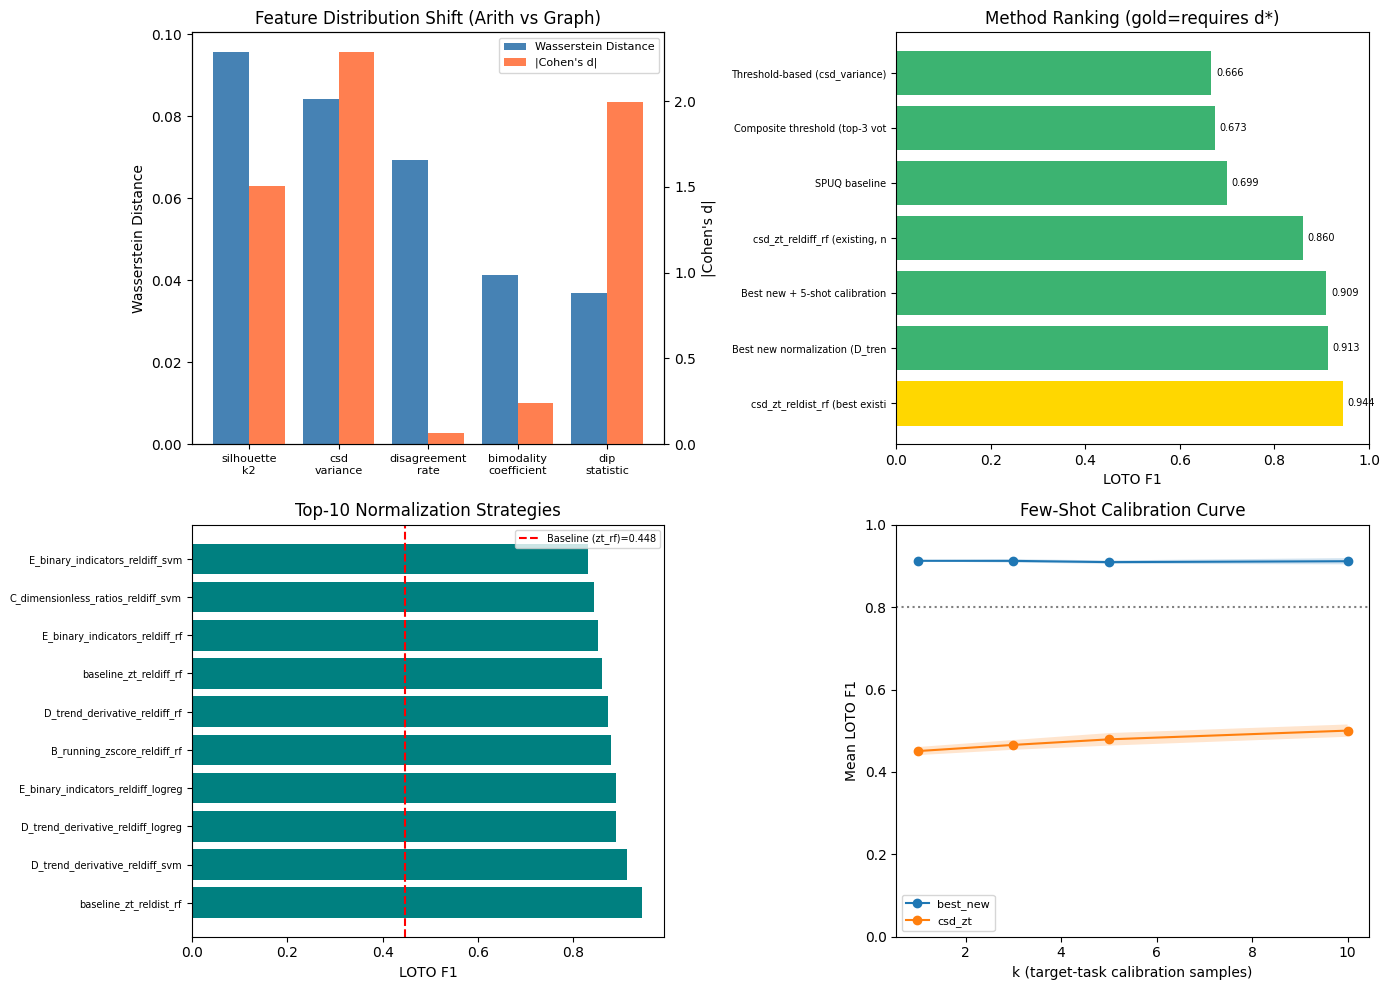

Visualization complete. Saved results_summary.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: Feature Distribution Shift ---
ax = axes[0, 0]
ranking = analysis_1["feature_shift_ranking"]
features = [r["feature"] for r in ranking]
wd_vals = [r["wasserstein_distance"] for r in ranking]
cd_vals = [r["cohens_d"] for r in ranking]
x = np.arange(len(features))
bars = ax.bar(x - 0.2, wd_vals, 0.4, label="Wasserstein Distance", color="steelblue")
ax2 = ax.twinx()
bars2 = ax2.bar(x + 0.2, cd_vals, 0.4, label="|Cohen's d|", color="coral")
ax.set_xticks(x)
ax.set_xticklabels([f.replace("_", "\n") for f in features], fontsize=8)
ax.set_ylabel("Wasserstein Distance")
ax2.set_ylabel("|Cohen's d|")
ax.set_title("Feature Distribution Shift (Arith vs Graph)")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=8)

# --- Plot 2: Method Ranking ---
ax = axes[0, 1]
methods = [m["method"][:30] for m in analysis_4["method_ranking"]]
f1s = [m["loto_f1"] for m in analysis_4["method_ranking"]]
colors = ["gold" if m["requires_d_star"] else "mediumseagreen" for m in analysis_4["method_ranking"]]
bars = ax.barh(range(len(methods)), f1s, color=colors)
ax.set_yticks(range(len(methods)))
ax.set_yticklabels(methods, fontsize=7)
ax.set_xlabel("LOTO F1")
ax.set_title("Method Ranking (gold=requires d*)")
ax.set_xlim(0, 1.0)
for i, v in enumerate(f1s):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=7)

# --- Plot 3: Top-5 Normalization Strategies LOTO F1 ---
ax = axes[1, 0]
strat_f1s = []
for strat_name, strat_data in analysis_2["strategies"].items():
    for clf_name, clf_data in strat_data["classifiers"].items():
        strat_f1s.append((f"{strat_name}_{clf_name}", clf_data["loto_f1"]))
strat_f1s.sort(key=lambda x: x[1], reverse=True)
top_n = min(10, len(strat_f1s))
top_strats = strat_f1s[:top_n]
names = [s[0][:35] for s in top_strats]
vals = [s[1] for s in top_strats]
ax.barh(range(top_n), vals, color="teal")
ax.set_yticks(range(top_n))
ax.set_yticklabels(names, fontsize=7)
ax.set_xlabel("LOTO F1")
ax.set_title(f"Top-{top_n} Normalization Strategies")
ax.axvline(x=BASELINE_LOTO_F1, color="red", linestyle="--", label=f"Baseline (zt_rf)={BASELINE_LOTO_F1}")
ax.legend(fontsize=7)

# --- Plot 4: Few-Shot Calibration Curve ---
ax = axes[1, 1]
for config_name, config_data in analysis_3.get("calibration_curve", {}).items():
    ks = sorted([int(k) for k in config_data.keys()])
    mean_f1s = [config_data[str(k)]["mean_f1"] for k in ks]
    ci_lo = [config_data[str(k)]["ci_95_lower"] for k in ks]
    ci_hi = [config_data[str(k)]["ci_95_upper"] for k in ks]
    ax.plot(ks, mean_f1s, "o-", label=config_name)
    ax.fill_between(ks, ci_lo, ci_hi, alpha=0.2)
ax.set_xlabel("k (target-task calibration samples)")
ax.set_ylabel("Mean LOTO F1")
ax.set_title("Few-Shot Calibration Curve")
ax.legend(fontsize=8)
ax.set_ylim(0, 1.0)
ax.axhline(y=0.8, color="gray", linestyle=":", label="F1=0.8 threshold")

plt.tight_layout()
plt.savefig("results_summary.png", dpi=100, bbox_inches="tight")
plt.show()
print("Visualization complete. Saved results_summary.png")